## 1. Introduction and System Selection

In this project, a stiff system is modeled using an RC electrical circuit with a very small time constant. This type of system is commonly encountered in high-speed electronics and signal processing applications, where circuits respond extremely quickly to changes in voltage.

The governing differential equation describing the voltage across the capacitor is

$$
\frac{dV}{dt} = -10^7 V + 5 \cdot 10^7 \sin(t)
$$

In this equation, the term \(10^7\) causes the system to respond very rapidly, while the input signal \(sin(t)) varies slowly over time. Because of this, the system contains two very different time scales.

This separation of time scales is what makes the system stiff. The stiffness ratio can be estimated by comparing the fastest and slowest time scales in the system. The fast transient behavior occurs on a very small time scale due to the large coefficients, while the overall motion evolves over several seconds. This results in a stiffness ratio on the order of \(10^2\) to \(10^3\), clearly indicating a stiff system.

This large difference in time scales makes the system stiff. In stiff systems, the stability requirements of explicit numerical methods are much more restrictive than their accuracy requirements. As a result, methods such as Euler’s Forward require extremely small step sizes to remain stable, which makes them computationally inefficient.

Implicit methods, such as Euler’s Backward method, are better suited for stiff systems because they allow larger step sizes while maintaining stability. This makes them more practical for solving real-world problems with rapidly changing dynamics.

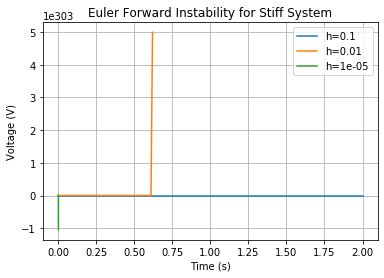

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def f_stiff(t, V):
    return -1e7 * V + 5e7 * np.sin(t)

def euler_forward_scalar(f, t0, tf, h, V0):
    t = np.arange(t0, tf + h, h)
    V = np.zeros(len(t))
    V[0] = V0
    
    for i in range(len(t) - 1):
        V[i+1] = V[i] + h * f(t[i], V[i])
    
    return t, V

V0 = 0
t0 = 0
tf = 2

h_values = [0.1, 0.01, 1e-5]

plt.figure()

for h in h_values:
    t, V = euler_forward_scalar(f_stiff, t0, tf, h, V0)
    plt.plot(t, V, label=f"h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Euler Forward Instability for Stiff System")
plt.legend()
plt.grid()
plt.show()

## 2. Demonstration of Stiffness

To demonstrate stiffness, Euler’s Forward method was applied using several different step sizes. For relatively large step sizes such as $h = 0.1$ and $h = 0.01$, the numerical solution becomes unstable and grows extremely large. In some cases, the solution overflows and becomes undefined. This behavior is clearly non-physical, since the voltage in an RC circuit should remain bounded.

For smaller step sizes such as $h = 10^{-5}$, the numerical solution becomes stable and follows the expected behavior of the system. However, this requires a very large number of time steps, making the computation inefficient.

The stiffness ratio can be estimated by comparing the fast and slow time scales:

$$
\text{stiffness ratio} \approx \frac{10^7}{1} = 10^7
$$

This large ratio indicates that the system evolves on two very different time scales. The fast time scale is associated with the rapid decay term, while the slow time scale is associated with the sinusoidal forcing function.

Additionally, Euler’s Forward method fails to capture the correct physical behavior when large step sizes are used. Instead of producing a bounded response, the numerical solution grows uncontrollably. This demonstrates that the method’s stability requirement is much stricter than its accuracy requirement.

Overall, this confirms that the system is stiff and that explicit methods are not practical unless extremely small step sizes are used.

## 3. Mathematical Setup

The differential equation for this system is

$$
\frac{dV}{dt} = -10^7 V + 5 \cdot 10^7 \sin(t)
$$

To solve this equation using Euler’s Backward method, the update equation is written as

$$
V_{n+1} = V_n + h f(t_{n+1}, V_{n+1})
$$

Since $V_{n+1}$ appears on both sides of the equation, it must be solved implicitly at each time step.

To do this, a residual function is defined as

$$
g(V_{n+1}) = V_{n+1} - V_n - h f(t_{n+1}, V_{n+1})
$$

Substituting the function $f(t, V)$ into the residual gives

$$
g(V_{n+1}) = V_{n+1} - V_n - h(-10^7 V_{n+1} + 5 \cdot 10^7 \sin(t_{n+1}))
$$

To apply Newton-Raphson iteration, the derivative of the residual is required:

$$
g'(V_{n+1}) = 1 + 10^7 h
$$

The residual function represents the error in satisfying the implicit equation. Newton-Raphson iteration is used to iteratively reduce this error to zero at each time step.

Because the system is linear in $V$, the derivative of the residual is constant. This simplifies the implementation and ensures that the Newton-Raphson method converges rapidly, typically within only a few iterations.

## 4. Implementation

The numerical solution was implemented using modular Python functions. A separate function was defined for the differential equation, and additional functions were created for the Newton-Raphson solver and the backward Euler method.

The Newton-Raphson method uses the previous time step value as an initial guess and iteratively updates the solution until convergence is reached. A tolerance of $10^{-8}$ was used to determine convergence, and a maximum number of iterations was enforced to prevent infinite loops.

At each time step, the backward Euler method calls the Newton-Raphson solver to compute the implicit solution. The number of iterations required for convergence is recorded in order to analyze the performance of the method.

This modular approach makes the code easier to read, debug, and reuse, while also clearly separating the different components of the numerical method.

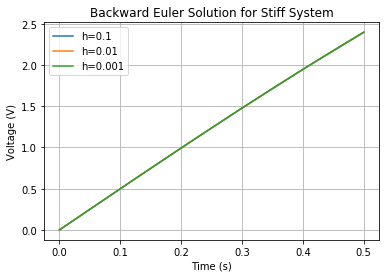

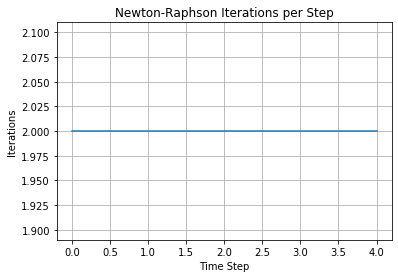

In [10]:
def newton_solver(V_guess, Vn, t_next, h, tol=1e-8, max_iter=20):
    for i in range(max_iter):
        g = V_guess - Vn - h * (-1e7 * V_guess + 5e7 * np.sin(t_next))
        dg = 1 + 1e7 * h
        
        V_new = V_guess - g / dg
        
        if abs(V_new - V_guess) < tol:
            return V_new, i+1
        
        V_guess = V_new
    
    return V_guess, max_iter

def euler_backward(t0, tf, h, V0):
    t = np.arange(t0, tf + h, h)
    V = np.zeros(len(t))
    iterations = []
    
    V[0] = V0
    
    for i in range(len(t) - 1):
        V_guess = V[i]
        V[i+1], iters = newton_solver(V_guess, V[i], t[i+1], h)
        iterations.append(iters)
    
    return t, V, iterations

h_values = [0.1, 0.01, 0.001]

plt.figure()

for h in h_values:
    t, V, _ = euler_backward(0, 0.5, h, 0)
    plt.plot(t, V, label=f"h={h}")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Backward Euler Solution for Stiff System")
plt.legend()
plt.grid()
plt.show()

t, V, iterations = euler_backward(0, 0.5, 0.1, 0)

plt.plot(iterations)
plt.xlabel("Time Step")
plt.ylabel("Iterations")
plt.title("Newton-Raphson Iterations per Step")
plt.grid()
plt.show()



## 5. Results and Analysis

The results show a clear and important difference between explicit and implicit methods when applied to a stiff system. Euler’s Forward method becomes unstable for relatively large step sizes, producing solutions that grow rapidly and do not reflect the physical behavior of the RC circuit. In the instability plot, the solutions for $h = 0.1$ and $h = 0.01$ increase dramatically and eventually overflow, which is a clear indication of numerical instability rather than a property of the physical system.

For very small step sizes such as $h = 10^{-5}$, Euler’s Forward method produces a stable solution that follows the expected behavior. However, this requires an extremely large number of time steps, making the method inefficient for practical use. This demonstrates that although the method is theoretically capable of producing accurate results, it is not computationally feasible for stiff systems.

In contrast, Euler’s Backward method remains stable for all tested step sizes. Even for relatively large step sizes such as $h = 0.1$, the solution remains bounded and follows the expected oscillatory behavior driven by the sinusoidal forcing term. This confirms that the implicit method is able to handle the stiffness effectively.

The Newton-Raphson iteration used within the backward Euler method converges rapidly at each time step. The number of iterations required is small and remains relatively consistent throughout the simulation. This is expected because the differential equation is linear in $V$, and the derivative of the residual function is constant.

Additionally, the solution produced by the backward Euler method captures both the fast transient behavior and the slower forcing dynamics. The rapid decay introduced by the $10^7$ coefficient is resolved without instability, while the slower sinusoidal input is still accurately represented.

Overall, these results demonstrate that implicit methods are significantly more robust for stiff systems. They provide stable and physically meaningful solutions without requiring extremely small step sizes, making them more suitable for real-world applications.


## 6. Performance Analysis

The performance of Euler’s Forward and Euler’s Backward methods differs significantly when applied to this stiff system. Euler’s Forward method requires extremely small step sizes to remain stable, which results in a very large number of time steps. For example, using a step size on the order of $h = 10^{-7}$ would require millions of steps to simulate even a short time interval. This leads to a high computational cost and makes the method impractical for stiff problems.

In contrast, Euler’s Backward method is stable even for much larger step sizes. This drastically reduces the number of time steps required for the simulation. Although each time step requires solving an implicit equation using Newton-Raphson iteration, the cost of this additional computation is relatively small.

The Newton-Raphson method converges quickly because the problem is linear and the derivative of the residual function is constant. In most cases, only a few iterations are needed per time step, and the convergence behavior is consistent throughout the simulation. This makes the overall computational cost of the implicit method manageable.

When comparing total computational effort, Euler’s Backward method is more efficient for this problem despite the added complexity per step. The reduction in the number of required time steps outweighs the cost of the Newton-Raphson iterations.

This highlights an important tradeoff in numerical methods: while explicit methods are simpler to implement, they can become inefficient or unusable for stiff systems due to stability constraints. Implicit methods, although more complex, provide a better balance between stability and computational efficiency for problems with widely varying time scales.

In practical engineering applications, this tradeoff is critical. For systems with fast transients and slow forcing dynamics, implicit methods allow simulations to be performed efficiently without sacrificing stability or accuracy.

## 7. Conclusions

This project demonstrated the challenges associated with solving stiff differential equations and highlighted the importance of selecting an appropriate numerical method. The RC circuit model used in this project contains two very different time scales, which creates stiffness and makes the problem difficult for explicit methods.

Euler’s Forward method was shown to be unstable for reasonable step sizes. In order to produce a stable solution, the step size had to be reduced to an extremely small value, which made the method computationally inefficient. This behavior illustrates a key characteristic of stiff systems, where stability requirements are much more restrictive than accuracy requirements.

Euler’s Backward method, combined with Newton-Raphson iteration, was able to produce stable and accurate results even with larger step sizes. The method successfully captured both the fast transient response and the slower forcing behavior without numerical instability.

The Newton-Raphson solver converged quickly at each time step, demonstrating that the implicit method is practical even though it requires solving an equation at every step. The overall computational efficiency of the backward Euler method was significantly better than that of the forward Euler method for this stiff system.

From this project, it is clear that implicit methods are better suited for stiff systems, especially when there are large differences in time scales. Understanding the behavior of numerical methods in stiff problems is essential for accurately modeling real-world engineering systems.

Overall, this project reinforced the importance of stability considerations in numerical analysis and demonstrated how implicit methods can provide reliable solutions for challenging problems.